# pdivt continuous kludge with modified constraints

In [1]:
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt

## Set up
Run a once-through large tokamak to initialise values.

In [2]:
# TODO Apparently need to run once-through?
# single_run = SingleRun("large_tokamak_IN.DAT")
single_run = SingleRun("large_tokamak_once_through_high_W_and_He_new_var_names_IN.DAT")
single_run.run()

The IN.DAT file does not contain any obsolete variables.
 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
 Git Tag :
 Git Branch :
 Date : 12/03/2025 UTC
 Time : 09:20
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/impurities
 Input : /home/jon/code/notebooks/impurities/large_tokamak_once_through_high_W_and_He_new_var_names_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 ********************************************************************************

/home/jon/code/process-fork/process/init.py:39: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process()
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for reactor is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for power plant is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for reactor is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for power plant is in error by more than 5 MW.


 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.


process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for reactor is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for power plant is in error by more than 5 MW.


 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.


process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for reactor is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for power plant is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for reactor is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for power plant is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.


 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.


process.power - WARNING - WARNING: Power balance for reactor is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance for power plant is in error by more than 5 MW.


 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
 87     2   OUTPLAS: Possible problem with high radiation power, forcing pdivt to odd values
 Floating point diagnostic values for this error:
   1)    4.29153E-30
  
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
 93     2   BURN: Negative burn time available; reduce t_fusion_ramp or raise PF coil V-s ca
 Floating point diagnostic values for this error:
   1)   -1.00000E+01
   2)   -0.00000E+00
   3)    4.55350E-02
   4)    1.00000E+01
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
 87     2   OUTPLAS: Possible problem with high radiation power, forcing pdivt to odd values
 Floating point diagnostic values for this error:
   1)    3.73388E-30
  
244     2   PHYSICS: Diamagneti

## Study: parameter scan of W impurity fraction

In [3]:
def run_impurities(w_imp_fracs):
    """Calculate responses to W impurities."""
    n = w_imp_fracs.shape[0]
    p_plasma_rad_mw = np.empty(n)
    pdivt = np.empty(n)
    p_l_h_threshold_mw = np.empty(n)
    con15 = np.empty(n)

    for i, imp_frac in enumerate(w_imp_fracs):
        process.fortran.impurity_radiation_module.impurity_arr_frac[13] = imp_frac
        single_run.models.physics.physics()

        # Evaluate constraint equation 15 (L-H threshold constraint)
        con15_value, _, _, _, _ = process.fortran.constraints.constraint_eqn_015()

        # Need to copy values
        p_plasma_rad_mw[i] = process.fortran.physics_variables.p_plasma_rad_mw.item()
        pdivt[i] = process.fortran.physics_variables.pdivt.item()
        p_l_h_threshold_mw[i] = (
            process.fortran.physics_variables.p_l_h_threshold_mw.item()
        )
        con15[i] = -con15_value

    return p_plasma_rad_mw, pdivt, p_l_h_threshold_mw, con15

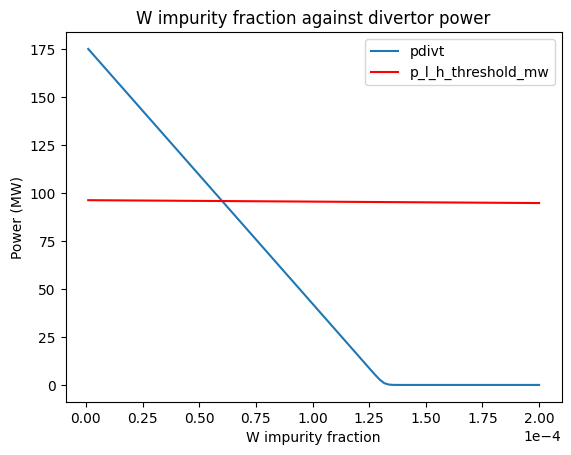

In [4]:
HE_FRAC_SOLUTION = 0.060238763988650204
process.fortran.physics_variables.f_nd_alpha_electron = HE_FRAC_SOLUTION
w_imp_fracs_high = np.linspace(1.0e-6, 2.0e-4, 100)
p_plasma_rad_mw, pdivt, p_l_h_threshold_mw, con15 = run_impurities(w_imp_fracs_high)

fig, ax = plt.subplots()
# ax.scatter(w_imp_fracs_high, p_plasma_rad_mw, label="p_plasma_rad_mw")
ax.plot(w_imp_fracs_high, pdivt, label="pdivt")
ax.plot(w_imp_fracs_high, p_l_h_threshold_mw, "r", label="p_l_h_threshold_mw")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax.set_title("W impurity fraction against divertor power")
ax.set_xlabel("W impurity fraction")
ax.set_ylabel("Power (MW)")
ax.legend()

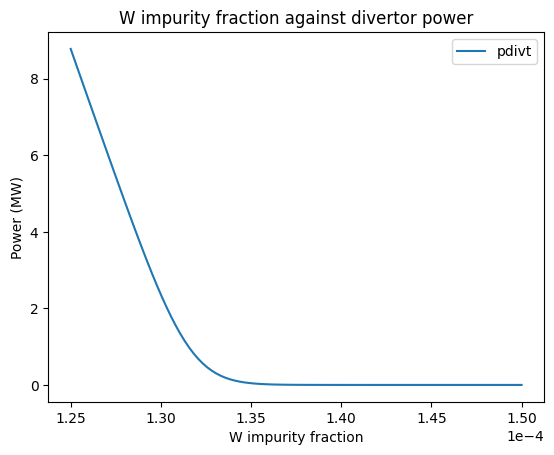

In [5]:
HE_FRAC_SOLUTION = 0.060238763988650204
process.fortran.physics_variables.f_nd_alpha_electron = HE_FRAC_SOLUTION
w_imp_fracs_high = np.linspace(1.25e-4, 1.5e-4, 100)
p_plasma_rad_mw, pdivt, p_l_h_threshold_mw, con15 = run_impurities(w_imp_fracs_high)

fig, ax = plt.subplots()
# ax.scatter(w_imp_fracs_high, p_plasma_rad_mw, label="p_plasma_rad_mw")
ax.plot(w_imp_fracs_high, pdivt, label="pdivt")
# ax.plot(w_imp_fracs_high, p_l_h_threshold_mw, "r", label="p_l_h_threshold_mw")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax.set_title("W impurity fraction against divertor power")
ax.set_xlabel("W impurity fraction")
ax.set_ylabel("Power (MW)")
ax.legend()

## Plot for pdivt and L-H constraint value

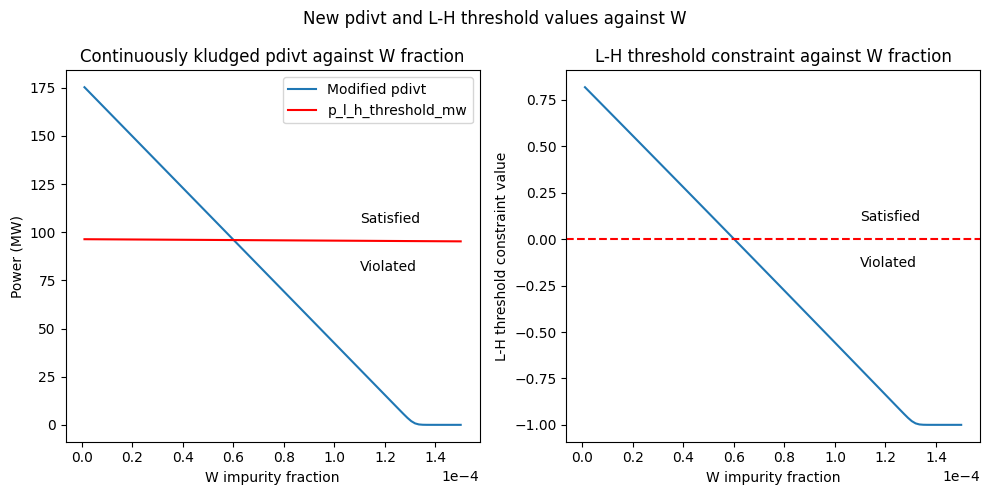

In [20]:
w_imp_fracs_high = np.linspace(1.0e-6, 1.5e-4, 100)
p_plasma_rad_mw, pdivt, p_l_h_threshold_mw, con15 = run_impurities(w_imp_fracs_high)

fig, ax = plt.subplots(ncols=2, sharex=True)
fig.set_figwidth(10)
fig.set_figheight(5)
# pdivt plot
ax[0].plot(w_imp_fracs_high, pdivt, label="Modified pdivt")
ax[0].plot(w_imp_fracs_high, p_l_h_threshold_mw, "r", label="p_l_h_threshold_mw")
ax[0].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0].set_title("Continuously kludged pdivt against W fraction")
ax[0].set_xlabel("W impurity fraction")
ax[0].set_ylabel("Power (MW)")
ax[0].legend()
ax[0].annotate("Satisfied", (1.1e-4, 105))
ax[0].annotate("Violated", (1.1e-4, 80))
# Constraint plot
ax[1].plot(w_imp_fracs_high, con15, label="con15")
ax[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax[1].set_title("L-H threshold constraint against W fraction")
ax[1].set_xlabel("W impurity fraction")
ax[1].set_ylabel("L-H threshold constraint value")
ax[1].axhline(0.0, color="r", ls="--")
ax[1].annotate("Satisfied", (1.1e-4, 0.1))
ax[1].annotate("Violated", (1.1e-4, -0.15))

fig.suptitle("New pdivt and L-H threshold values against W")
fig.tight_layout()